論文「TimeDRL: Disentangled Representation Learning for Multivariate Time-Series」的詳細分析：

(1) 問題描述

多變量時間序列資料在醫療保健和工業等領域中具有重要價值，但由於缺乏標籤和高維度特性，對其進行分析和建模充滿挑戰。現有的自我監督學習方法雖然能在無標籤資料中學習豐富的表示，但在學習解耦的嵌入表示以及處理如轉換不變性等歸納偏差問題上仍存在不足。因此，該研究旨在開發一種能夠有效學習解耦表示的框架，以提升多變量時間序列資料的分析能力。

(2) 前人研究及其不足

先前的研究主要集中在以下兩個方面：

時間戳級別嵌入學習：一些方法專注於從時間序列資料中提取時間戳級別的嵌入表示，用於預測和異常檢測。然而，這些方法未能同時考慮實例級別的嵌入，限制了模型在分類和聚類任務中的表現。

實例級別嵌入學習：另一些方法則專注於學習實例級別的嵌入，用於分類和聚類任務，但忽略了時間戳級別的資訊，導致在處理需要細粒度時間資訊的任務（如預測）時表現不佳。

此外，許多方法依賴於資料增強技術，如裁剪和遮罩，這可能引入不適當的歸納偏差，特別是在時間序列資料中，這些增強技術可能破壞時間依賴性，導致模型學習到不正確的表示。

(3) 提出看法

為了解決上述問題，作者提出了TimeDRL框架，該框架具有以下特點：

解耦的雙層嵌入學習：通過在時間序列資料中引入[CLS]標記，從而同時學習時間戳級別和實例級別的嵌入，避免了僅依賴於池化方法提取實例級別嵌入所帶來的各向異性問題。

雙重自我監督任務：設計了時間戳預測任務和實例對比任務，前者優化時間戳級別的嵌入，後者優化實例級別的嵌入，從而實現解耦的表示學習。

避免資料增強引入的歸納偏差：在自我監督學習過程中，避免使用可能引入不適當歸納偏差的資料增強技術，如裁剪和遮罩，轉而利用如dropout等技術引入隨機性，生成不同的嵌入視圖，從而提高模型的泛化能力。

(4) 嚴謹定義名詞

時間戳級別嵌入（Timestamp-level Embedding）：表示時間序列中每個時間點的嵌入，用於捕捉細粒度的時間資訊，適用於預測和異常檢測等任務。

實例級別嵌入（Instance-level Embedding）：表示整個時間序列實例的嵌入，用於捕捉全局資訊，適用於分類和聚類等任務。

各向異性問題（Anisotropy Problem）：指嵌入表示集中在嵌入空間的狹窄區域，限制了表示的表達能力，導致模型性能下降。

歸納偏差（Inductive Bias）：在機器學習中，指模型在學習過程中所依賴的先驗知識或假設，可能影響模型的泛化能力。

(5) 嚴謹提出定理或理論

在TimeDRL框架中，作者提出了一種基於[CLS]標記的策略，從patched時間序列資料中解耦地導出時間戳級別和實例級別的嵌入。具體而言，通過在時間序列資料的開頭添加一個[CLS]標記，該標記的嵌入表示實例級別的資訊，而其餘的時間戳嵌入則表示時間戳級別的資訊。這種方法避免了僅依賴於池化方法提取實例級別嵌入所帶來的各向異性問題，從而提高了嵌入表示的表達能力。

(6) 模型架構

TimeDRL的模型架構包括以下組件：

資料分片（Data Patching）：將原始時間序列資料劃分為固定長度的片段，每個片段包含多個連續的時間步。

[CLS]標記引入：在每個片段的開頭添加一個[CLS]標記，用於學習實例級別的嵌入表示。

編碼器（Encoder）：使用基於Transformer的編碼器對包含[CLS]標記的片段進行編碼，生成時間戳級別和實例級別的嵌入。

自我監督任務：

時間戳預測任務：使用解碼器從時間戳級別的嵌入重建原始的時間序列資料，以確保時間戳級別的嵌入能夠保留時間序列的資訊。

實例對比任務：使用對比學習方法（如SimCLR）來最大化相同實例的不同視圖（通過dropout生成）之間的相似度，以提升實例級別嵌入的區分能力。

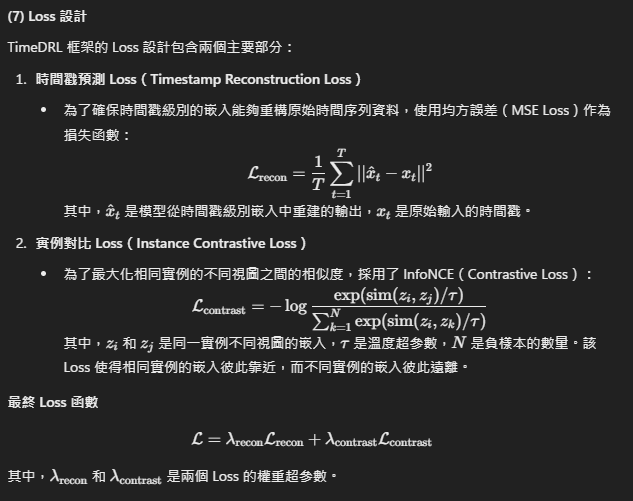

(8) 訓練過程

資料預處理

對原始多變量時間序列進行標準化處理，以確保不同變數之間的尺度一致。
將時間序列劃分為固定長度的片段，並在每個片段的開頭添加[CLS]標記。
模型訓練

將處理後的時間序列輸入 Transformer 編碼器，提取時間戳級別和實例級別的嵌入。
設計雙重自我監督任務，分別針對時間戳級別和實例級別的嵌入進行優化。
透過 Adam 優化器訓練模型，學習時間戳級別和實例級別的表徵。
使用 dropout 技術來產生不同的視圖，以進行對比學習，而非依賴於傳統的資料增強方法（如遮罩和裁剪）。
模型驗證

在不同的下游任務（分類、異常檢測等）上評估模型的性能，並與現有的自我監督學習方法進行比較。
(9) 最終結果

分類與聚類性能提升

TimeDRL 在多個時間序列分類和聚類基準數據集（如 UEA, PhysioNet）上顯著超越了現有的自監督學習方法，如 TS2Vec、TNC 和 CoST。
在異常檢測任務中，TimeDRL 也表現良好，因為解耦的嵌入學習能夠更清楚地識別異常模式。
避免了各向異性問題

透過解耦的雙層嵌入學習方法，TimeDRL 有效減少了嵌入空間的各向異性問題，提高了表示的表達能力。
避免了不適當的資料增強

與現有方法不同，TimeDRL 透過 dropout 產生不同的視圖來進行對比學習，而非傳統的時間序列增強方法（如裁剪、遮罩），這避免了引入潛在的不適當歸納偏差。
總結
TimeDRL 是一種專門為多變量時間序列設計的自我監督學習框架，透過解耦的雙層嵌入學習方法來同時學習時間戳級別和實例級別的表示，並且利用雙重自我監督任務（時間戳預測與實例對比學習）來提升模型的學習能力。該框架不僅有效解決了時間序列嵌入學習中的各向異性問題，還避免了傳統資料增強方法可能帶來的不適當歸納偏差，並在多個基準測試中表現出色。

c:\Users\jhbai\Anaconda\envs\MachineLearningEnv\Lib\site-packages\torch\nn\modules\transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch 1/100, Loss: 4.3348
Epoch 2/100, Loss: 3.3567
Epoch 3/100, Loss: 3.1808
Epoch 4/100, Loss: 3.0394
Epoch 5/100, Loss: 2.9787
Epoch 6/100, Loss: 2.9039
Epoch 7/100, Loss: 2.8610
Epoch 8/100, Loss: 2.8365
Epoch 9/100, Loss: 2.7867
Epoch 10/100, Loss: 2.7356
Epoch 11/100, Loss: 2.7162
Epoch 12/100, Loss: 2.6748
Epoch 13/100, Loss: 2.6608
Epoch 14/100, Loss: 2.6143
Epoch 15/100, Loss: 2.5950
Epoch 16/100, Loss: 2.5760
Epoch 17/100, Loss: 2.5519
Epoch 18/100, Loss: 2.5115
Epoch 19/100, Loss: 2.5023
Epoch 20/100, Loss: 2.4874
Epoch 21/100, Loss: 2.4725
Epoch 22/100, Loss: 2.4580
Epoch 23/100, Loss: 2.4439
Epoch 24/100, Loss: 2.4229
Epoch 25/100, Loss: 2.4125
Epoch 26/100, Loss: 2.4147
Epoch 27/100, Loss: 2.3964
Epoch 28/100, Loss: 2.3819
Epoch 29/100, Loss: 2.3588
Epoch 30/100, Loss: 2.3560
Epoch 31/100, Loss: 2.3324
Epoch 32/100, Loss: 2.3468
Epoch 33/100, Loss: 2.3236
Epoch 34/100, Loss: 2.3015
Epoch 35/100, Loss: 2.3024
Epoch 36/100, Loss: 2.2933
Epoch 37/100, Loss: 2.2928
Epoch 38/1

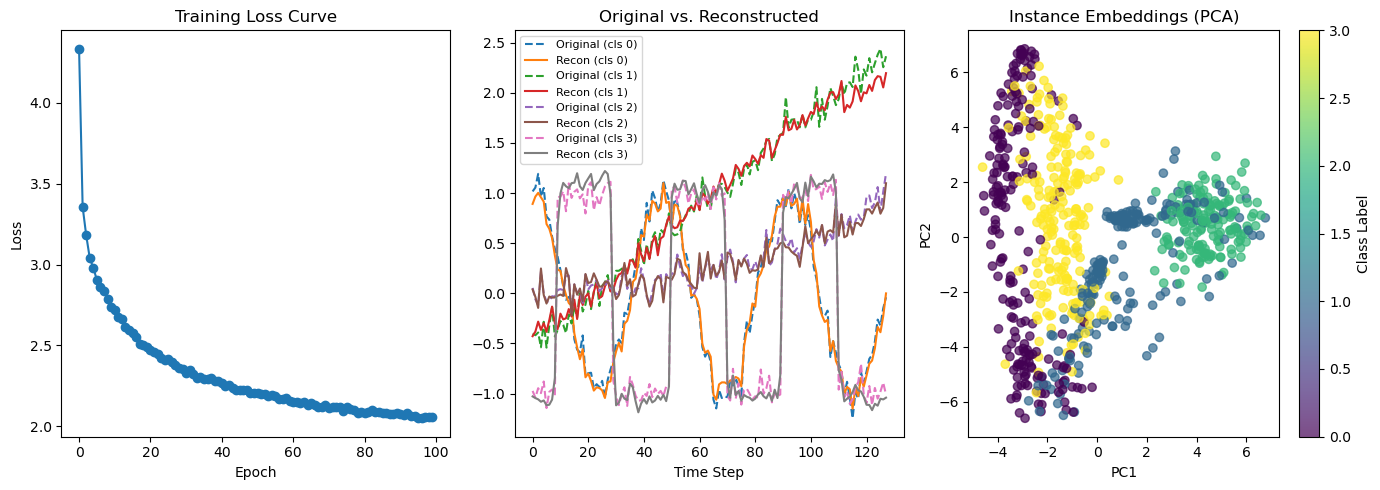

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA

###############################################################################
# 1. 定義 TimeDRL 模型（保持論文架構與 Loss 設計）
###############################################################################

class TimeDRL(nn.Module):
    def __init__(self, input_dim, patch_size, num_patches, model_dim, num_heads, num_layers, dropout=0.1):
        """
        參數說明：
        - input_dim: 輸入時間序列特徵數（多變量時間序列中的變數數量）
        - patch_size: 每個 patch 包含的時間步長數量
        - num_patches: 每筆時間序列分成的 patch 數量 (total_length // patch_size)
        - model_dim: Transformer 模型隱藏層維度
        - num_heads: Transformer 中 Multi-Head Attention 的 head 數量
        - num_layers: Transformer Encoder 層數
        - dropout: dropout 比例
        """
        super(TimeDRL, self).__init__()
        self.patch_size = patch_size
        self.num_patches = num_patches
        self.model_dim = model_dim

        # 將每個 patch（形狀：patch_size x input_dim）拉平成一個向量後投影到 model_dim 維度
        self.patch_embed = nn.Linear(patch_size * input_dim, model_dim)
        
        # 定義 [CLS] 標記，用於學習整個實例的全局嵌入
        self.cls_token = nn.Parameter(torch.zeros(1, 1, model_dim))
        
        # 位置嵌入（包含 [CLS] token 與所有 patch）
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, model_dim))
        
        # dropout 層
        self.dropout = nn.Dropout(dropout)
        
        # 定義 Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 解碼器：將每個 token 表示還原成 patch 對應的原始維度
        self.decoder = nn.Linear(model_dim, patch_size * input_dim)
        
        self._init_weights()
        
    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.xavier_uniform_(self.patch_embed.weight)
        nn.init.constant_(self.patch_embed.bias, 0)
        nn.init.xavier_uniform_(self.decoder.weight)
        nn.init.constant_(self.decoder.bias, 0)
        
    def forward(self, x):
        """
        輸入 x: shape = (batch_size, total_length, input_dim)
        假設 total_length = patch_size * num_patches
        輸出：
         - instance_embedding: [CLS] token 表示 (batch_size, model_dim)
         - recon_time_series: 重建的整個時間序列 (batch_size, total_length, input_dim)
         - patch_embeddings: 每個 patch 的 token 表示 (batch_size, num_patches, model_dim)
        """
        batch_size = x.size(0)
        # 劃分 patch，reshape 成 (batch_size, num_patches, patch_size * input_dim)
        x = x.view(batch_size, self.num_patches, self.patch_size * x.size(2))
        patch_embeddings = self.patch_embed(x)
        
        # 準備 [CLS] 標記，擴展至批次維度
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        
        # 將 [CLS] 與 patch 嵌入串接
        tokens = torch.cat((cls_tokens, patch_embeddings), dim=1)
        tokens = tokens + self.pos_embed
        tokens = self.dropout(tokens)
        
        # Transformer Encoder 預期輸入 shape 為 (sequence_length, batch_size, model_dim)
        tokens = tokens.transpose(0, 1)
        tokens = self.transformer_encoder(tokens)
        tokens = tokens.transpose(0, 1)
        
        # 取出 [CLS] token 作為實例級別嵌入
        instance_embedding = tokens[:, 0, :]
        patch_tokens = tokens[:, 1:, :]
        
        # 利用解碼器重建每個 patch，再拼接成完整的時間序列
        patch_recon = self.decoder(patch_tokens)
        patch_recon = patch_recon.view(batch_size, self.num_patches, self.patch_size, -1)
        recon_time_series = patch_recon.reshape(batch_size, self.num_patches * self.patch_size, -1)
        
        return instance_embedding, recon_time_series, patch_tokens

###############################################################################
# 2. 定義 InfoNCE 對比 Loss（實例對比 Loss）
###############################################################################

def instance_contrastive_loss(z1, z2, temperature=0.5):
    """
    InfoNCE 對比損失：
    - z1 與 z2 為同一批次同一實例經不同 dropout 擾動後的 instance embedding
    """
    z1_norm = F.normalize(z1, dim=1)
    z2_norm = F.normalize(z2, dim=1)
    batch_size = z1.size(0)
    sim_matrix = torch.matmul(z1_norm, z2_norm.T) / temperature
    labels = torch.arange(batch_size).to(z1.device)
    loss_1 = F.cross_entropy(sim_matrix, labels)
    loss_2 = F.cross_entropy(sim_matrix.T, labels)
    loss = (loss_1 + loss_2) / 2.0
    return loss

###############################################################################
# 3. 訓練函數（保持原論文方法：雙重 forward 與雙 Loss 計算）
###############################################################################

def train_model(model, dataloader, num_epochs=50, lr=1e-4, lambda_recon=1.0, lambda_contrast=1.0, device='cuda'):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.to(device)
    mse_loss = nn.MSELoss()
    
    loss_history = []
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        for batch_data in dataloader:
            # 此處僅使用輸入資料（忽略標籤）
            batch = batch_data[0].to(device)
            optimizer.zero_grad()
            # 利用不同 dropout 擾動進行兩次 forward pass
            instance_emb_1, recon_1, _ = model(batch)
            instance_emb_2, recon_2, _ = model(batch)
            
            loss_recon = mse_loss(recon_1, batch) + mse_loss(recon_2, batch)
            loss_contrast = instance_contrastive_loss(instance_emb_1, instance_emb_2)
            loss = lambda_recon * loss_recon + lambda_contrast * loss_contrast
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(dataloader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
    return model, loss_history

###############################################################################
# 4. 產生多種不同的時間序列模擬資料
###############################################################################

def generate_synthetic_data(num_samples, total_length, input_dim=1):
    """
    產生多種類型的時間序列模擬：
    分為 4 類：
    0: 正弦波
    1: 線性趨勢
    2: 指數增長
    3: 方波
    """
    data = []
    labels = []
    t = np.linspace(0, 1, total_length)
    for i in range(num_samples):
        cls = np.random.randint(0, 4)  # 隨機選取類別 0~3
        if cls == 0:
            # 正弦波：隨機頻率與相位
            freq = np.random.uniform(1, 5)
            phase = np.random.uniform(0, 2*np.pi)
            signal = np.sin(2 * np.pi * freq * t + phase)
        elif cls == 1:
            # 線性趨勢：隨機斜率與截距
            slope = np.random.uniform(-3, 3)
            intercept = np.random.uniform(-1, 1)
            signal = slope * t + intercept
        elif cls == 2:
            # 指數增長：隨機指數，做簡單正規化
            exponent = np.random.uniform(1, 3)
            signal = np.exp(exponent * t) - 1  # 起始值為 0
            signal = signal / np.max(signal)
        elif cls == 3:
            # 方波：由正弦波取符號產生
            freq = np.random.uniform(1, 5)
            phase = np.random.uniform(0, 2*np.pi)
            signal = np.sign(np.sin(2 * np.pi * freq * t + phase))
        # 加入少量雜訊
        noise = np.random.normal(0, 0.1, size=signal.shape)
        signal = signal + noise
        # 若 input_dim > 1，則重複信號
        signal = np.repeat(signal[:, np.newaxis], input_dim, axis=1)
        data.append(signal)
        labels.append(cls)
    data = np.array(data, dtype=np.float32)  # shape: (num_samples, total_length, input_dim)
    labels = np.array(labels)
    return data, labels

###############################################################################
# 5. 視覺化結果：訓練曲線、原始與重建時間序列、以及 instance embedding 分佈
###############################################################################

def visualize_results(model, dataset, loss_history, patch_size, device='cuda'):
    """
    視覺化包含：
    1. 訓練損失曲線
    2. 原始與重建時間序列對比（各類別選取一筆樣本）
    3. 利用 PCA 降維後的 instance embedding 分佈（以不同顏色區分不同類別）
    """
    model.eval()
    data, labels = dataset
    data_tensor = torch.tensor(data).to(device)
    with torch.no_grad():
        instance_embeddings, reconstructions, _ = model(data_tensor)
    instance_embeddings = instance_embeddings.cpu().numpy()
    reconstructions = reconstructions.cpu().numpy()
    
    # 利用 PCA 將 instance embeddings 降維至 2D
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(instance_embeddings)
    
    plt.figure(figsize=(14, 5))
    
    # 圖 1: 訓練 Loss 曲線
    plt.subplot(1, 3, 1)
    plt.plot(loss_history, marker='o')
    plt.title("Training Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    
    # 圖 2: 原始 vs. 重建時間序列（各類別各選一筆）
    plt.subplot(1, 3, 2)
    for cls in range(4):
        idx = np.where(labels == cls)[0]
        if len(idx) == 0:
            continue
        sample_idx = idx[0]
        original = data[sample_idx].squeeze()  # shape: (total_length,)
        recon = reconstructions[sample_idx].squeeze()  # shape: (total_length,)
        plt.plot(original, label=f"Original (cls {cls})", linestyle='--')
        plt.plot(recon, label=f"Recon (cls {cls})")
    plt.title("Original vs. Reconstructed")
    plt.xlabel("Time Step")
    plt.legend(fontsize=8)
    
    # 圖 3: Instance Embeddings 降維後分佈
    plt.subplot(1, 3, 3)
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels, cmap='viridis', alpha=0.7)
    plt.title("Instance Embeddings (PCA)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar(scatter, label="Class Label")
    
    plt.tight_layout()
    plt.show()

###############################################################################
# 6. 主程式：資料準備、模型訓練與視覺化展示
###############################################################################

def main():
    torch.manual_seed(42)
    np.random.seed(42)
    
    # 資料設定：每筆時間序列長度 total_length，特徵維度 input_dim (設為1便於視覺化)
    total_length = 128
    input_dim = 1
    num_samples = 800   # 總樣本數
    patch_size = 16
    num_patches = total_length // patch_size
    
    # 產生多種類型的時間序列及其標籤
    data, labels = generate_synthetic_data(num_samples, total_length, input_dim)
    
    # 建立 TensorDataset 與 DataLoader
    tensor_data = torch.tensor(data)
    tensor_labels = torch.tensor(labels, dtype=torch.long)
    dataset = TensorDataset(tensor_data, tensor_labels)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
    
    # 模型參數設定
    model_dim = 64    # Transformer 隱藏層維度
    num_heads = 4     # Multi-head Attention 數量
    num_layers = 2    # Transformer Encoder 層數
    dropout = 0.1
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # 初始化模型
    model = TimeDRL(input_dim=input_dim, patch_size=patch_size, num_patches=num_patches,
                    model_dim=model_dim, num_heads=num_heads, num_layers=num_layers, dropout=dropout)
    
    # 訓練模型，並記錄訓練損失歷程以便視覺化
    num_epochs = 100
    trained_model, loss_history = train_model(model, dataloader, num_epochs=num_epochs, lr=1e-4,
                                              lambda_recon=1.0, lambda_contrast=1.0, device=device)
    
    # 將資料與標籤整理為視覺化用資料集
    dataset_for_viz = (data, labels)
    visualize_results(trained_model, dataset_for_viz, loss_history, patch_size, device=device)

if __name__ == '__main__':
    main()
